In [1]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv

--2026-05-18 07:23:18--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 178509 (174K) [text/plain]
Saving to: ‘BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv’

BTC_USD_2013-10-01_ 100%[===================>] 174.33K  --.-KB/s    in 0.01s   

2026-05-18 07:23:18 (11.7 MB/s) - ‘BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv’ saved [178509/178509]



In [2]:
import pandas as pd

df = pd.read_csv('/content/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv',
                 parse_dates=['Date'],
                 index_col=['Date']
)
df.head()

,Currency,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
Date,,,,,
2013-10-01,BTC,123.65499,124.30466,124.75166,122.56349
2013-10-02,BTC,125.45500,123.65499,125.75850,123.63383
2013-10-03,BTC,108.58483,125.45500,125.66566,83.32833
2013-10-04,BTC,118.67466,108.58483,118.67500,107.05816
2013-10-05,BTC,121.33866,118.67466,121.93633,118.00566


In [3]:
bitcoin_prices = pd.DataFrame(df['Closing Price (USD)']).rename(columns={'Closing Price (USD)': 'price'})
bitcoin_prices.head()

,price
Date,
2013-10-01,123.65499
2013-10-02,125.45500
2013-10-03,108.58483
2013-10-04,118.67466
2013-10-05,121.33866


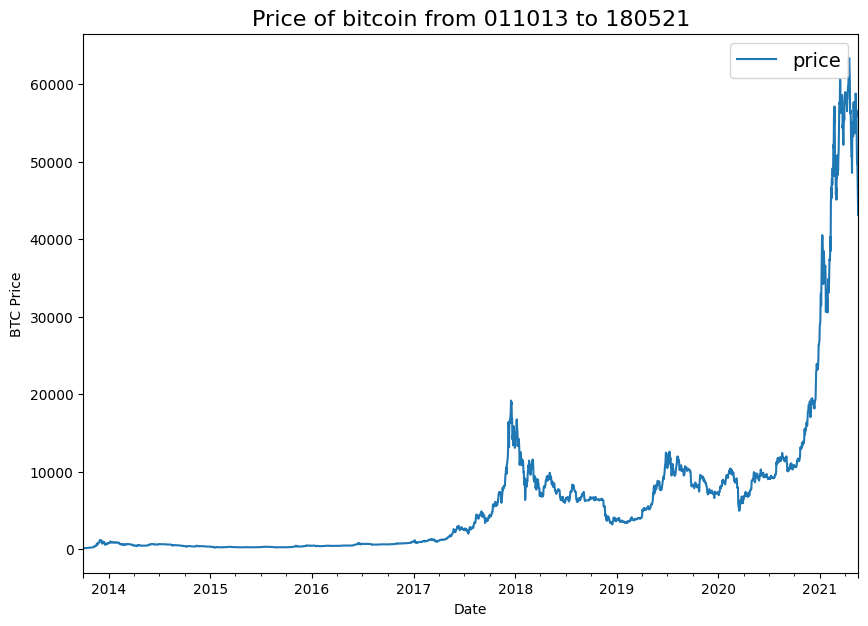

In [4]:
import matplotlib.pyplot as plt

bitcoin_prices.plot(figsize=(10,7))
plt.ylabel('BTC Price')
plt.title('Price of bitcoin from 011013 to 180521', fontsize=16)
plt.legend(fontsize=14)

In [5]:
import csv
from datetime import datetime

timesteps=[]
btc_price=[]
with open('/content/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv','r') as f:
  csv_reader = csv.reader(f, delimiter=',')
  next(csv_reader)
  for line in csv_reader:
    timesteps.append(datetime.strptime(line[1],'%Y-%m-%d'))
    btc_price.append(float(line[2]))

timesteps[:5], btc_price[:5]

([datetime.datetime(2013, 10, 1, 0, 0),
  datetime.datetime(2013, 10, 2, 0, 0),
  datetime.datetime(2013, 10, 3, 0, 0),
  datetime.datetime(2013, 10, 4, 0, 0),
  datetime.datetime(2013, 10, 5, 0, 0)],
 [123.65499, 125.455, 108.58483, 118.67466, 121.33866])

Text(0.5, 1.0, 'Price of bitcoin from 011013 to 180521')

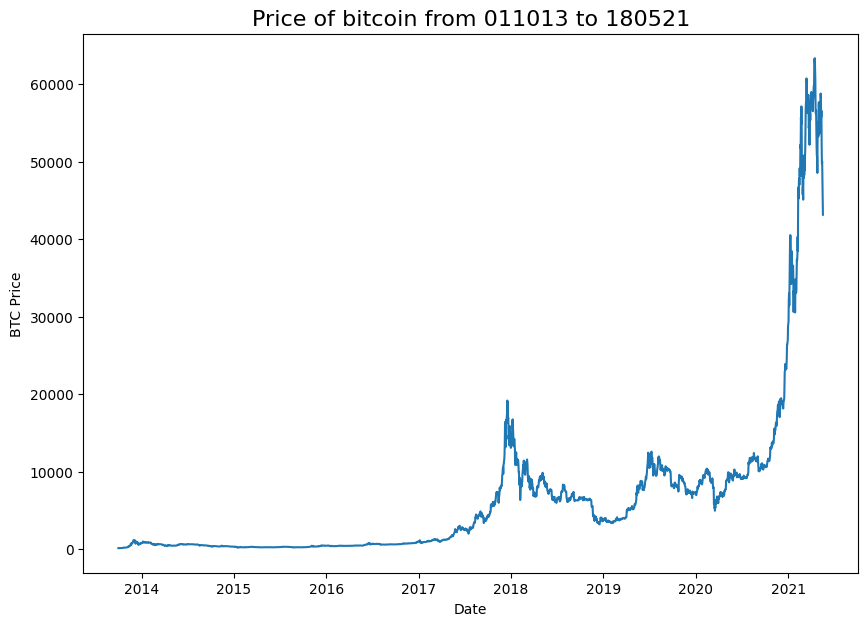

In [6]:
plt.figure(figsize=(10,7))
plt.plot(timesteps, btc_price)
plt.ylabel('BTC Price')
plt.xlabel('Date')
plt.title('Price of bitcoin from 011013 to 180521', fontsize=16)


In [7]:
bitcoin_prices[:5]

,price
Date,
2013-10-01,123.65499
2013-10-02,125.45500
2013-10-03,108.58483
2013-10-04,118.67466
2013-10-05,121.33866


In [8]:
timesteps = bitcoin_prices.index.to_numpy()
prices = bitcoin_prices['price'].to_numpy()

timesteps[:5], prices[:5]

(array(['2013-10-01T00:00:00.000000000', '2013-10-02T00:00:00.000000000',
        '2013-10-03T00:00:00.000000000', '2013-10-04T00:00:00.000000000',
        '2013-10-05T00:00:00.000000000'], dtype='datetime64[ns]'),
 array([123.65499, 125.455  , 108.58483, 118.67466, 121.33866]))

In [9]:
split_size = int(0.8*len(prices))

X_train, y_train = timesteps[:split_size], prices[:split_size]
X_test, y_test = timesteps[split_size:], prices[split_size:]

len(X_train), len(y_train), len(X_test), len(y_test)

(2229, 2229, 558, 558)

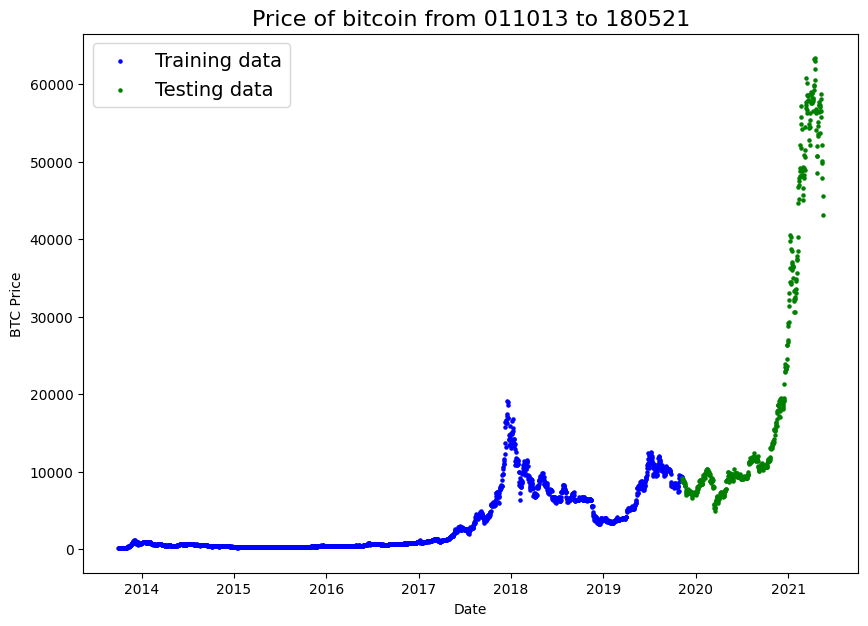

In [10]:
plt.figure(figsize=(10,7))
plt.scatter(X_train, y_train, c='b', s=5, label='Training data')
plt.scatter(X_test, y_test, c='g', s=5,label='Testing data')
plt.ylabel('BTC Price')
plt.xlabel('Date')
plt.title('Price of bitcoin from 011013 to 180521', fontsize=16)
plt.legend(fontsize=14)


In [11]:
def plot_time_series(timesteps, values, format='.', start=0, end=None, label=None):
  plt.plot(timesteps[start:end], values[start:end], format, label=label)
  plt.xlabel('Time')
  plt.ylabel('BTC Price')
  if label:
    plt.legend(fontsize=14)
  plt.grid(True)

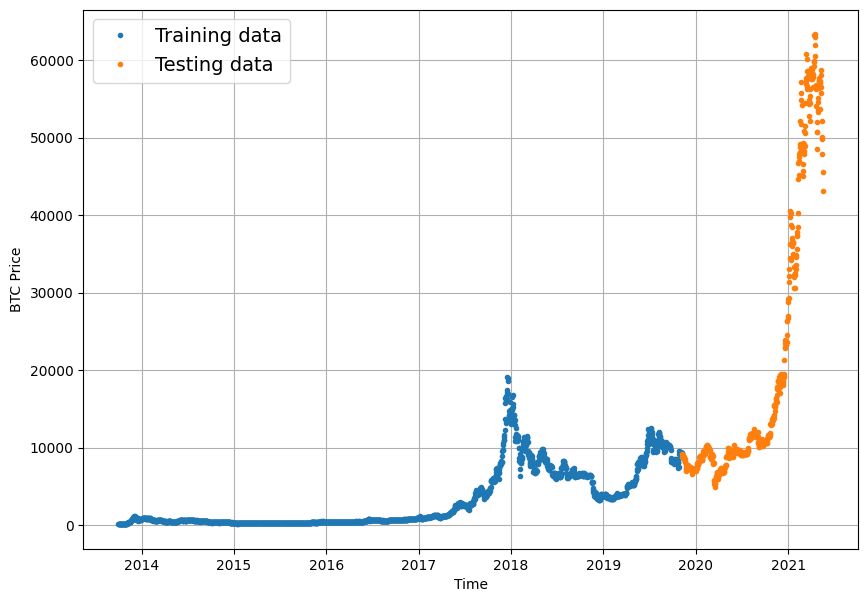

In [12]:
plt.figure(figsize=(10,7))
plot_time_series(timesteps=X_train, values=y_train, label='Training data')
plot_time_series(timesteps=X_test, values=y_test, label='Testing data')

In [13]:
naive_forecast = y_test[:-1]
naive_forecast[:10], naive_forecast[-10:]

(array([9226.48582088, 8794.35864452, 8798.04205463, 9081.18687849,
        8711.53433917, 8760.89271814, 8749.52059102, 8656.97092235,
        8500.64355816, 8469.2608989 ]),
 array([57107.12067189, 58788.20967893, 58102.19142623, 55715.54665129,
        56573.5554719 , 52147.82118698, 49764.1320816 , 50032.69313676,
        47885.62525472, 45604.61575361]))

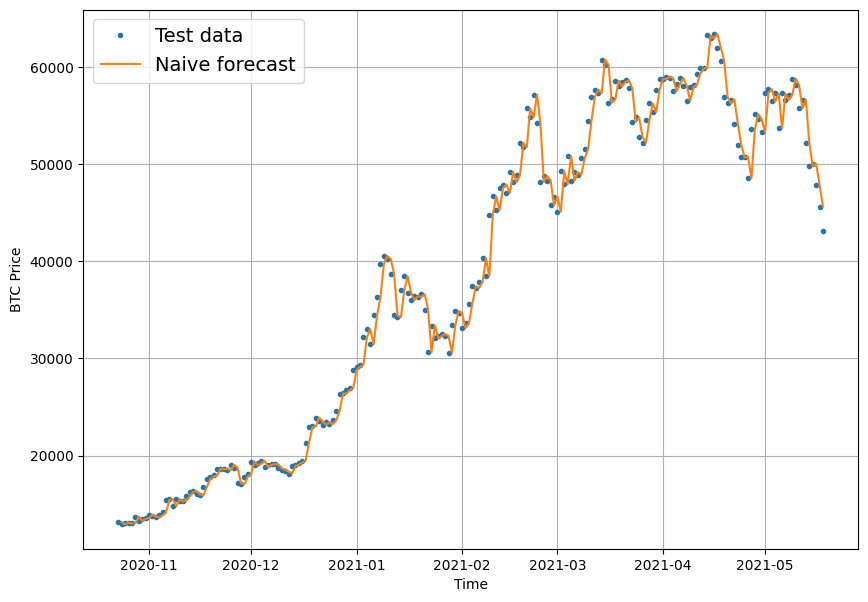

In [14]:
plt.figure(figsize=(10,7))
#plot_time_series(timesteps=X_train, values=y_train, label='Train data')
plot_time_series(timesteps=X_test, values=y_test, start=350,label='Test data')
plot_time_series(timesteps=X_test[1:], values=naive_forecast, start=350,format='-', label='Naive forecast')

In [15]:
import tensorflow as tf

def mean_absolute_scaled_error(y_true, y_pred):
  mae = tf.reduce_mean(tf.abs(y_true-y_pred))
  mae_naive_no_season = tf.reduce_mean(tf.abs(y_true[1:]-y_true[:-1]))
  return mae/mae_naive_no_season

In [16]:
mean_absolute_scaled_error(y_test[1:], naive_forecast).numpy()

np.float64(0.9995699939182624)

In [17]:
import tensorflow as tf

def evaluate_preds(y_true, y_pred):
  y_true = tf.cast(y_true, dtype=tf.float32)
  y_pred = tf.cast(y_pred, dtype=tf.float32)


  mae_metric = tf.keras.metrics.MeanAbsoluteError()
  mse_metric = tf.keras.metrics.MeanSquaredError()
  mape_metric = tf.keras.metrics.MeanAbsolutePercentageError()


  mae_metric.update_state(y_true, y_pred)
  mse_metric.update_state(y_true, y_pred)
  mape_metric.update_state(y_true, y_pred)


  mae = mae_metric.result().numpy().item()
  mse = mse_metric.result().numpy().item()
  rmse = tf.sqrt(mse).numpy().item()
  mape = mape_metric.result().numpy().item()
  mase = mean_absolute_scaled_error(y_true, y_pred).numpy().item()


  return {
      'mae': mae,
      'mse': mse,
      'rmse': rmse,
      'mape': mape,
      'mase': mase
  }

In [18]:
naive_results = evaluate_preds(y_true=y_test[1:], y_pred=naive_forecast)
naive_results

{'mae': 567.980224609375,
 'mse': 1147547.0,
 'rmse': 1071.2362060546875,
 'mape': 2.5165250301361084,
 'mase': 0.9995700120925903}

In [19]:
HORIZON=1
WINDOW_SIZE = 7

In [20]:
def get_labelled_windows(x, horizon=HORIZON):
  return x[:, :-horizon], x[:, -horizon:]


In [21]:
test_window, test_label = get_labelled_windows(tf.expand_dims(tf.range(8), axis=0))
print(f'Window: {tf.squeeze(test_window).numpy()}')
print(f'Label: {tf.squeeze(test_label).numpy()}')

Window: [0 1 2 3 4 5 6]
Label: 7


In [22]:
import numpy as np

def make_windows(x, window_size=WINDOW_SIZE, horizon=HORIZON):
  window_step= np.expand_dims(np.arange(window_size+horizon), axis=0)
  window_indexes = window_step + np.expand_dims(np.arange(len(x)-(window_size+horizon-1)), axis=0).T
  #print(f'Window indexes:\n {window_indexes, window_indexes.shape}')
  windowed_array = x[window_indexes]
  windows, labels = get_labelled_windows(windowed_array, horizon=horizon)
  return windows, labels

In [23]:
make_windows(prices)

(array([[  123.65499   ,   125.455     ,   108.58483   , ...,
           121.33866   ,   120.65533   ,   121.795     ],
        [  125.455     ,   108.58483   ,   118.67466   , ...,
           120.65533   ,   121.795     ,   123.033     ],
        [  108.58483   ,   118.67466   ,   121.33866   , ...,
           121.795     ,   123.033     ,   124.049     ],
        ...,
        [58788.20967893, 58102.19142623, 55715.54665129, ...,
         52147.82118698, 49764.1320816 , 50032.69313676],
        [58102.19142623, 55715.54665129, 56573.5554719 , ...,
         49764.1320816 , 50032.69313676, 47885.62525472],
        [55715.54665129, 56573.5554719 , 52147.82118698, ...,
         50032.69313676, 47885.62525472, 45604.61575361]]),
 array([[  123.033     ],
        [  124.049     ],
        [  125.96116   ],
        ...,
        [47885.62525472],
        [45604.61575361],
        [43144.47129086]]))

In [24]:
full_windows, full_labels = make_windows(prices)
full_windows.shape, full_labels.shape

((2780, 7), (2780, 1))

In [25]:
for i in range(3):
  print(f'Window : {tf.squeeze(full_windows[i])}')
  print(f'Label : {tf.squeeze(full_labels[i])}')

Window : [123.65499 125.455   108.58483 118.67466 121.33866 120.65533 121.795  ]
Label : 123.033
Window : [125.455   108.58483 118.67466 121.33866 120.65533 121.795   123.033  ]
Label : 124.049
Window : [108.58483 118.67466 121.33866 120.65533 121.795   123.033   124.049  ]
Label : 125.96116


In [26]:
def make_train_test_splits(windows, labels, test_split=0.2):
  split_size = int(len(windows)* (1-test_split))
  train_windows = windows[:split_size]
  train_labels = labels[:split_size]
  test_windows = windows[split_size:]
  test_labels = labels[split_size:]
  return train_windows, train_labels, test_windows, test_labels

In [27]:
train_windows, train_labels, test_windows, test_labels = make_train_test_splits(full_windows, full_labels)
train_windows.shape, train_labels.shape, test_windows.shape, test_labels.shape

((2224, 7), (2224, 1), (556, 7), (556, 1))

In [28]:
train_windows[:5], train_labels[:5], test_windows[:5], test_labels[:5]

(array([[123.65499, 125.455  , 108.58483, 118.67466, 121.33866, 120.65533,
         121.795  ],
        [125.455  , 108.58483, 118.67466, 121.33866, 120.65533, 121.795  ,
         123.033  ],
        [108.58483, 118.67466, 121.33866, 120.65533, 121.795  , 123.033  ,
         124.049  ],
        [118.67466, 121.33866, 120.65533, 121.795  , 123.033  , 124.049  ,
         125.96116],
        [121.33866, 120.65533, 121.795  , 123.033  , 124.049  , 125.96116,
         125.27966]]),
 array([[123.033  ],
        [124.049  ],
        [125.96116],
        [125.27966],
        [125.9275 ]]),
 array([[9290.89660239, 9202.41545055, 9369.62808116, 9326.59962378,
         9335.75240233, 9226.48582088, 8794.35864452],
        [9202.41545055, 9369.62808116, 9326.59962378, 9335.75240233,
         9226.48582088, 8794.35864452, 8798.04205463],
        [9369.62808116, 9326.59962378, 9335.75240233, 9226.48582088,
         8794.35864452, 8798.04205463, 9081.18687849],
        [9326.59962378, 9335.75240233, 

In [29]:
np.array_equal(np.squeeze(train_labels[:-HORIZON-1]), y_train[WINDOW_SIZE:])

True

In [30]:
import os

def create_model_checkpoint(model_name, save_path='model_experiments'):
  return tf.keras.callbacks.ModelCheckpoint(filepath=os.path.join(save_path, model_name + '.keras'),
                                            verbose=0,
                                            save_best_only=True)

In [31]:
import tensorflow as tf
from tensorflow.keras import layers

tf.random.set_seed(42)

model_1 = tf.keras.Sequential(
    [
        layers.Dense(128, activation='relu'),
        layers.Dense(HORIZON, activation='linear')

    ], name='model_1_dense'
)

model_1.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae', 'mse']
)

model_1.fit(
    train_windows,
    train_labels,
    epochs=100,
    batch_size=128,
    validation_data=(test_windows, test_labels),
    callbacks=[create_model_checkpoint(model_name=model_1.name)]
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 689.0896 - mae: 689.0896 - mse: 1849831.7500 - val_loss: 1464.6360 - val_mae: 1464.6360 - val_mse: 6216234.5000
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 214.3795 - mae: 214.3795 - mse: 196092.6094 - val_loss: 1051.9984 - val_mae: 1051.9984 - val_mse: 3631551.2500
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 169.5492 - mae: 169.5492 - mse: 143781.2969 - val_loss: 871.6078 - val_mae: 871.6078 - val_mse: 2497396.7500
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 152.9870 - mae: 152.9870 - mse: 130847.3984 - val_loss: 863.1926 - val_mae: 863.1926 - val_mse: 2357011.0000
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 147.3825 - mae: 147.3825 - mse: 119167.1562 - val_loss: 814.3657 - val_mae: 814.3657 - val_mse: 2187674.0000
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 143.9619 - mae: 143.9619 - mse: 116678.2656 - val_loss: 799.8146 - val_mae: 799.8146 - val_mse:

In [32]:
model_1.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 579.3517 - mae: 579.3517 - mse: 1197777.5000


[579.3517456054688, 579.3517456054688, 1197777.5]

In [33]:
def make_preds(model, input_data):
  forecast = model.predict(input_data)
  return tf.squeeze(forecast)

In [34]:
model_1_preds = make_preds(model_1, test_windows)
model_1_preds[:10], len(model_1_preds)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([8893.509, 8811.308, 9068.363, 8840.981, 8765.053, 8736.466,
        8726.854, 8547.356, 8482.973, 8556.753], dtype=float32)>,
 556)

In [35]:
model_1_results = evaluate_preds(tf.squeeze
                                 (test_labels), model_1_preds)
model_1_results

{'mae': 579.3516845703125,
 'mse': 1197777.5,
 'rmse': 1094.43017578125,
 'mape': 2.6113438606262207,
 'mase': 1.0177603960037231}

In [36]:
naive_results

{'mae': 567.980224609375,
 'mse': 1147547.0,
 'rmse': 1071.2362060546875,
 'mape': 2.5165250301361084,
 'mase': 0.9995700120925903}

In [37]:
test_labels.shape, model_1_preds.shape

((556, 1), TensorShape([556]))

In [38]:
test_labels = tf.squeeze(test_labels)
test_labels[:10], model_1_preds[:10]

(<tf.Tensor: shape=(10,), dtype=float64, numpy=
 array([8798.04205463, 9081.18687849, 8711.53433917, 8760.89271814,
        8749.52059102, 8656.97092235, 8500.64355816, 8469.2608989 ,
        8537.33965197, 8205.80636599])>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([8893.509, 8811.308, 9068.363, 8840.981, 8765.053, 8736.466,
        8726.854, 8547.356, 8482.973, 8556.753], dtype=float32)>)

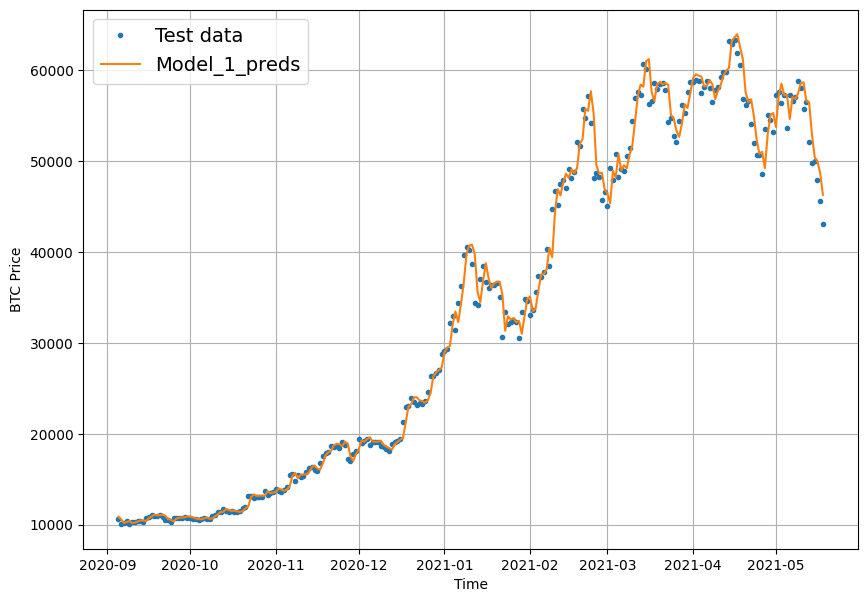

In [39]:
offset = 300
plt.figure(figsize=(10,7))
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels, start=offset, label='Test data')
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_1_preds, start=offset, format='-', label='Model_1_preds')

In [40]:
HORIZON=1
WINDOW_SIZE=30

full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

(2757, 2757)

In [41]:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(full_windows, full_labels, 0.2)
train_windows.shape, train_labels.shape, test_windows.shape, test_labels.shape

((2205, 30), (552, 30), (2205, 1), (552, 1))

In [42]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    layers.Dense(128, activation='relu'),
    layers.Dense(HORIZON, activation='linear')
], name='model_2_dense')

model_2.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae', 'mse']
)

# Corrected assignment of train/test splits
train_windows, train_labels, test_windows, test_labels = make_train_test_splits(full_windows, full_labels, 0.2)

model_2.fit(
    train_windows,
    train_labels,
    epochs=100,
    batch_size=128,
    validation_data=(test_windows, test_labels),
    callbacks=[create_model_checkpoint(model_name=model_2.name)]
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 2022.8160 - mae: 2022.8160 - mse: 16265361.0000 - val_loss: 1944.9968 - val_mae: 1944.9968 - val_mse: 10971653.0000
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 442.3748 - mae: 442.3748 - mse: 805048.5625 - val_loss: 2414.5437 - val_mae: 2414.5437 - val_mse: 14546424.0000
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 299.0453 - mae: 299.0453 - mse: 424907.9688 - val_loss: 1334.9651 - val_mae: 1334.9651 - val_mse: 5318531.0000
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 231.2935 - mae: 231.2935 - mse: 262791.5000 - val_loss: 1142.0170 - val_mae: 1142.0170 - val_mse: 4232026.5000
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 207.7880 - mae: 207.7880 - mse: 217115.5312 - val_loss: 1111.5604 - val_mae: 1111.5604 - val_mse: 4093646.0000
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 191.6311 - mae: 191.6311 - mse: 192443.5781 - val_loss: 1093.0272 - val_mae: 1093.02

In [43]:
model_2.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 615.3591 - mae: 615.3591 - mse: 1291606.6250


[615.359130859375, 615.359130859375, 1291606.625]

In [44]:
model_2 = tf.keras.models.load_model('model_experiments/model_2_dense.keras')
model_2.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 608.8445 - mae: 608.8445 - mse: 1276731.1250


[608.8445434570312, 608.8445434570312, 1276731.125]

In [45]:
model_2_preds= make_preds(model_2, test_windows)
model_2_preds[:10], len(model_2_preds)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([8737.783 , 8918.121 , 8848.309 , 8462.711 , 8343.283 , 8343.93  ,
        8138.817 , 8170.408 , 8069.777 , 7876.4185], dtype=float32)>,
 552)

In [46]:
model_2_results= evaluate_preds(tf.squeeze(test_labels), model_2_preds)
model_2_results, model_1_results, naive_results

({'mae': 608.8444213867188,
  'mse': 1276730.625,
  'rmse': 1129.925048828125,
  'mape': 2.8053138256073,
  'mase': 1.0642660856246948},
 {'mae': 579.3516845703125,
  'mse': 1197777.5,
  'rmse': 1094.43017578125,
  'mape': 2.6113438606262207,
  'mase': 1.0177603960037231},
 {'mae': 567.980224609375,
  'mse': 1147547.0,
  'rmse': 1071.2362060546875,
  'mape': 2.5165250301361084,
  'mase': 0.9995700120925903})

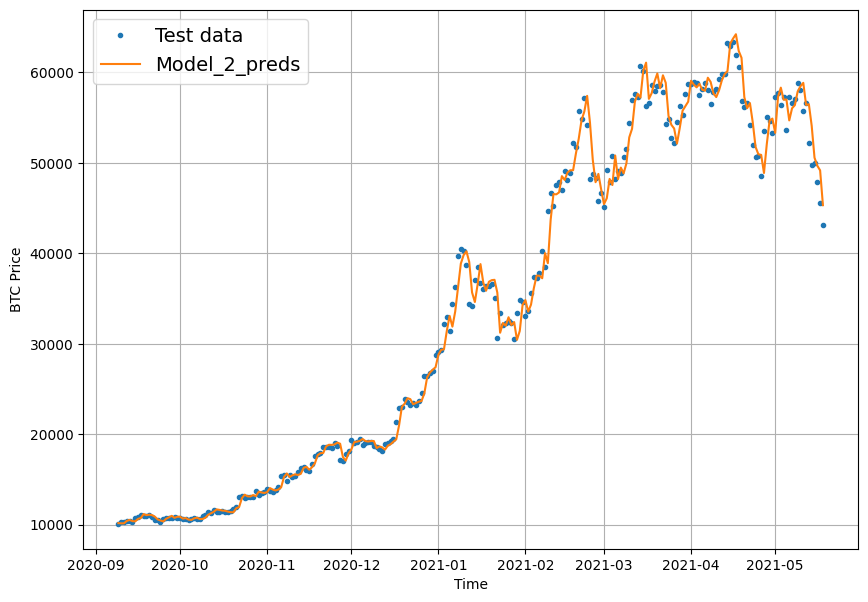

In [47]:
offset=300
plt.figure(figsize=(10,7))
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:,0], start=offset, label='Test data')
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_2_preds, start=offset, format='-', label='Model_2_preds')


In [48]:
HORIZON=7
WINDOWS=30

full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

(2751, 2751)

In [49]:
train_windows, train_labels, test_windows, test_labels = make_train_test_splits(full_windows,full_labels, 0.2)
len(train_windows), len(train_labels), len(test_windows), len(test_labels)

(2200, 2200, 551, 551)

In [50]:
tf.random.set_seed(42)

model_3 = tf.keras.Sequential([
    layers.Dense(128, activation='relu'),
    layers.Dense(HORIZON, activation='linear')
], name='model_3_dense')

model_3.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae', 'mse']
)

model_3.fit(
    train_windows,
    train_labels,
    epochs=100,
    batch_size=128,
    validation_data=(test_windows, test_labels),
    callbacks=[create_model_checkpoint(model_name=model_3.name)]
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 2297.7576 - mae: 2297.7576 - mse: 19184068.0000 - val_loss: 2528.2407 - val_mae: 2528.2407 - val_mse: 16900988.0000
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 563.6663 - mae: 563.6663 - mse: 1370330.8750 - val_loss: 2987.6121 - val_mae: 2987.6121 - val_mse: 23248480.0000
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 420.4456 - mae: 420.4456 - mse: 853681.0000 - val_loss: 2237.8384 - val_mae: 2237.8384 - val_mse: 14131283.0000
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 379.9282 - mae: 379.9282 - mse: 720515.5625 - val_loss: 1957.2413 - val_mae: 1957.2413 - val_mse: 11439672.0000
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 352.9405 - mae: 352.9405 - mse: 629565.1250 - val_loss: 1911.7432 - val_mae: 1911.7432 - val_mse: 10875664.0000
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 333.8371 - mae: 333.8371 - mse: 567403.1250 - val_loss: 1812.5792 - val_mae: 181

In [51]:
model_3.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1272.1538 - mae: 1272.1538 - mse: 5588494.5000


[1272.15380859375, 1272.15380859375, 5588494.5]

In [52]:
model_3 = tf.keras.models.load_model('model_experiments/model_3_dense.keras')
model_3.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1267.4331 - mae: 1267.4331 - mse: 5535445.0000


[1267.43310546875, 1267.43310546875, 5535445.0]

In [53]:
model_3_preds = make_preds(model_3, test_windows)
model_3_preds[:10], model_3_preds.shape

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


(<tf.Tensor: shape=(10, 7), dtype=float32, numpy=
 array([[9574.829 , 9584.216 , 9397.5   , 9418.223 , 9519.68  , 9414.934 ,
         9345.007 ],
        [9243.583 , 9116.12  , 9121.986 , 9226.368 , 9138.147 , 9181.07  ,
         8815.597 ],
        [9108.649 , 8919.1   , 9059.806 , 9123.74  , 8960.343 , 9157.446 ,
         8596.891 ],
        [9185.816 , 9148.467 , 9018.621 , 9189.32  , 9005.178 , 9264.636 ,
         8828.795 ],
        [9075.338 , 9027.76  , 8801.94  , 8897.942 , 8837.331 , 9112.969 ,
         8600.394 ],
        [9054.989 , 8991.174 , 8920.839 , 8784.117 , 8767.227 , 9060.898 ,
         8576.563 ],
        [9001.367 , 9009.2295, 9093.526 , 8868.728 , 8696.861 , 9029.884 ,
         8707.899 ],
        [8811.874 , 8964.429 , 8981.253 , 8851.417 , 8545.102 , 8758.112 ,
         8524.298 ],
        [8584.542 , 8693.549 , 8677.796 , 8759.591 , 8381.861 , 8429.113 ,
         8199.1455],
        [8573.69  , 8532.029 , 8432.843 , 8740.64  , 8178.825 , 8333.873 ,
         81

In [54]:
model_3_results = evaluate_preds(tf.squeeze(test_labels), model_3_preds)
model_3_results

{'mae': 1267.43310546875,
 'mse': 5535445.0,
 'rmse': 2352.752685546875,
 'mape': 5.74501895904541,
 'mase': 2.255326271057129}

In [55]:
model_3_preds.shape, model_2_preds.shape, model_1_preds.shape

(TensorShape([551, 7]), TensorShape([552]), TensorShape([556]))

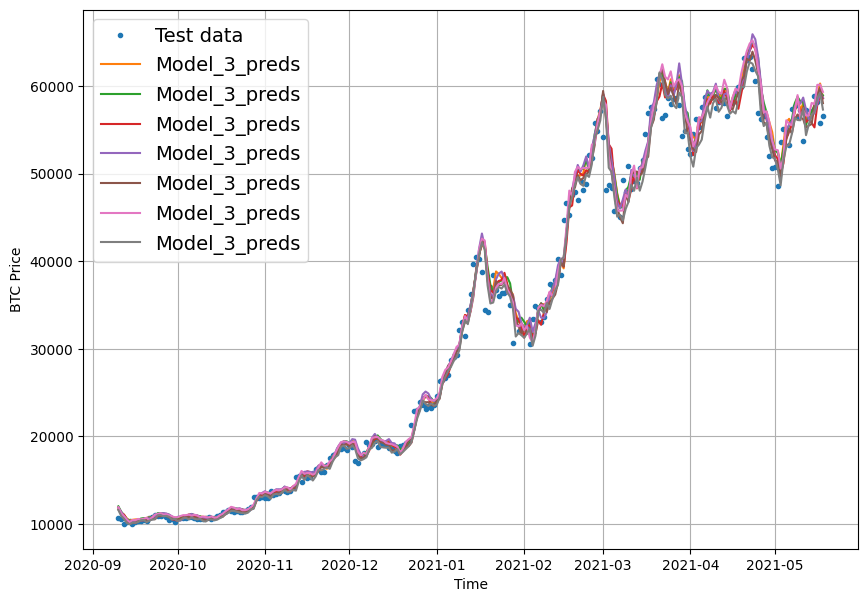

In [56]:
offset = 300
plt.figure(figsize=(10,7))
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:,0], start=offset, label='Test data')
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_3_preds, start=offset, format='-', label='Model_3_preds')


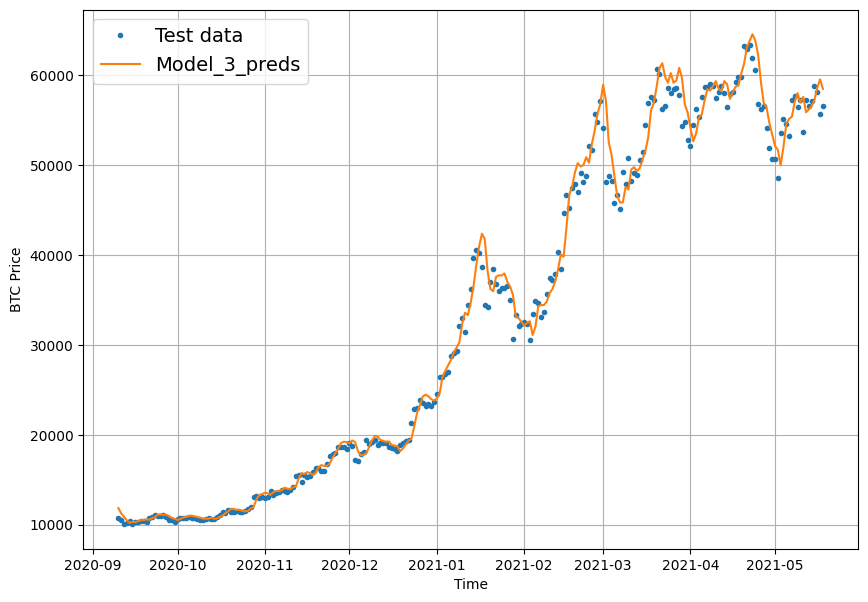

In [57]:
offset = 300
plt.figure(figsize=(10,7))
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:,0], start=offset, label='Test data')
plot_time_series(timesteps=X_test[-len(test_windows):], values=tf.reduce_mean(model_3_preds, axis=1), start=offset, format='-', label='Model_3_preds')


<Axes: >

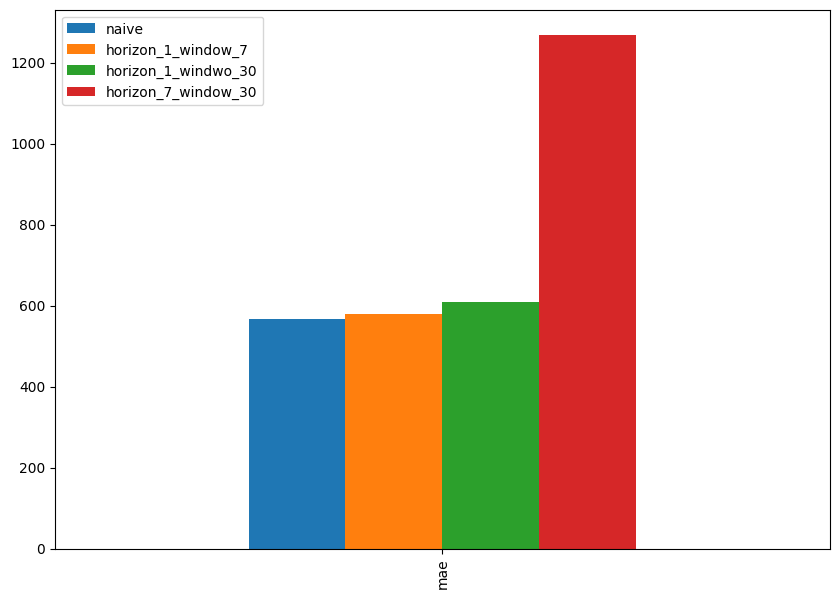

In [58]:
pd.DataFrame({
    'naive': naive_results['mae'],
    'horizon_1_window_7': model_1_results['mae'],
    'horizon_1_windwo_30': model_2_results['mae'],
    'horizon_7_window_30': model_3_results['mae']
}, index=['mae']).plot(kind='bar', figsize=(10,7))

In [59]:
HORIZON=1
WINDOW_SIZE=7

full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

(2780, 2780)

In [60]:
train_windows, train_labels, test_windows, test_labels = make_train_test_splits(full_windows, full_labels, 0.2)
len(train_windows), len(train_labels), len(test_windows), len(test_labels)

(2224, 2224, 556, 556)

In [61]:
train_windows.shape, train_labels.shape, test_windows.shape, test_labels.shape

((2224, 7), (2224, 1), (556, 7), (556, 1))

In [62]:
x=tf.constant(train_windows[0])
x.shape

TensorShape([7])

In [63]:
expand_dims_layer = layers.Lambda(lambda x: tf.expand_dims(x, axis=1))

In [64]:
print(f'Original shape: {x.shape}')
print(f'Expanded shape: {expand_dims_layer(x).shape}')
print(f'Original values with expanded dims:\n {expand_dims_layer(x)}')

Original shape: (7,)
Expanded shape: (7, 1)
Original values with expanded dims:
 [[123.65499]
 [125.455  ]
 [108.58483]
 [118.67466]
 [121.33866]
 [120.65533]
 [121.795  ]]


In [65]:
tf.random.set_seed(42)

class ExpandDims(tf.keras.layers.Layer):
    def __init__(self, axis, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.expand_dims(inputs, axis=self.axis)

    def get_config(self):             # ← needed for saving/loading
        config = super().get_config()
        config.update({'axis': self.axis})
        return config

model_4 = tf.keras.Sequential([
    ExpandDims(axis=1),
    layers.Conv1D(filters=128, kernel_size=3, padding='causal', activation='relu'),
    layers.Dense(HORIZON)
], name='model_4_conv1d')

model_4.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae', 'mse']
)

model_4.fit(
    train_windows,
    train_labels,
    epochs=100,
    batch_size=128,
    validation_data=(test_windows, test_labels),
    callbacks=[create_model_checkpoint(model_name=model_4.name)]
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 2725.2520 - mae: 2725.2520 - mse: 19506176.0000 - val_loss: 7537.5137 - val_mae: 7537.5137 - val_mse: 101896792.0000
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 504.8174 - mae: 504.8174 - mse: 961647.4375 - val_loss: 1849.1005 - val_mae: 1849.1005 - val_mse: 9247718.0000
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 235.3102 - mae: 235.3102 - mse: 230178.9219 - val_loss: 1060.2511 - val_mae: 1060.2511 - val_mse: 3712658.7500
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 198.4189 - mae: 198.4189 - mse: 196526.0781 - val_loss: 1161.9796 - val_mae: 1161.9796 - val_mse: 3987029.2500
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 189.9169 - mae: 189.9169 - mse: 189025.3906 - val_loss: 1130.9991 - val_mae: 1130.9991 - val_mse: 3836068.2500
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 185.9285 - mae: 185.9285 - mse: 182470.7812 - val_loss: 1090.6417 - val_mae: 1090.64

In [66]:
model_4.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 566.7817 - mae: 566.7817 - mse: 1172773.7500


[566.78173828125, 566.78173828125, 1172773.75]

In [67]:
model_4.load_weights('model_experiments/model_4_conv1d.keras')

model_4.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 566.7818 - mae: 566.7818 - mse: 1172773.7500


[566.7817993164062, 566.7817993164062, 1172773.75]

In [68]:
model_4 = tf.keras.models.load_model(
    'model_experiments/model_4_conv1d.keras',
    custom_objects={'ExpandDims': ExpandDims},
    safe_mode=False
)

model_4.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 566.7817 - mae: 566.7817 - mse: 1172773.5000


[566.7816772460938, 566.7816772460938, 1172773.5]

In [69]:
model_4_preds= make_preds(model_4, test_windows)
model_4_preds.shape

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


TensorShape([556])

In [70]:
model_4_results = evaluate_preds(tf.squeeze(test_labels), model_4_preds)
model_4_results

{'mae': 566.78173828125,
 'mse': 1172773.875,
 'rmse': 1082.9468994140625,
 'mape': 2.542827844619751,
 'mase': 0.9956785440444946}

In [71]:
tf.random.set_seed(42)

inputs = layers.Input(shape=(WINDOW_SIZE,))
x = ExpandDims(axis=1)(inputs)
x = layers.LSTM(128, activation='relu',return_sequences=True)(x)
x = layers.LSTM(128, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(HORIZON)(x)

model_5 = tf.keras.Model(inputs=inputs, outputs=outputs, name='model_5_LSTM')

model_5.compile(
    loss='mae',
    optimizer=tf.keras.optimizers.Adam()
    )

model_5.fit(
    train_windows,
    train_labels,
    epochs=100,
    batch_size=128,
    validation_data=(test_windows, test_labels),
    callbacks=[create_model_checkpoint(model_name=model_5.name)]
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 179ms/step - loss: 2835.0474 - val_loss: 14698.8271
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1101.4299 - val_loss: 1238.8328
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 198.5438 - val_loss: 1157.2513
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 183.9701 - val_loss: 1066.7657
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 183.1495 - val_loss: 1076.3289
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 178.5558 - val_loss: 1015.0104
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 174.5612 - val_loss: 988.3461
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 173.2637 - val_loss: 988.3013
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 170.0088 - val_loss: 961.5341
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 172.2069 - val_loss: 958.2532
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 168.3342 - val_loss: 940.7385
Epoch 1

In [72]:
model_5 = tf.keras.models.load_model('model_experiments/model_5_LSTM.keras',custom_objects={'ExpandDims': ExpandDims},
    safe_mode=False)
model_5.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 577.0237


577.023681640625

In [73]:
model_5_preds=make_preds(model_5, test_windows)
model_5_preds[:5]

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


<tf.Tensor: shape=(5,), dtype=float32, numpy=array([8872.768, 8785.142, 9029.513, 8772.318, 8704.865], dtype=float32)>

In [74]:
model_5_results = evaluate_preds(tf.squeeze(test_labels), model_5_preds )
model_5_results

{'mae': 577.0236206054688,
 'mse': 1195985.0,
 'rmse': 1093.6109619140625,
 'mape': 2.5726726055145264,
 'mase': 1.0136706829071045}

In [75]:
model_1_results, naive_results

({'mae': 579.3516845703125,
  'mse': 1197777.5,
  'rmse': 1094.43017578125,
  'mape': 2.6113438606262207,
  'mase': 1.0177603960037231},
 {'mae': 567.980224609375,
  'mse': 1147547.0,
  'rmse': 1071.2362060546875,
  'mape': 2.5165250301361084,
  'mase': 0.9995700120925903})

In [76]:
block_reward_1 = 50
block_reward_2 = 25
block_reward_3 = 12.5
block_reward_4 = 6.25

block_reward_2_datetime = np.datetime64('2012-11-28')
block_reward_3_datetime = np.datetime64('2016-07-09')
block_reward_4_datetime = np.datetime64('2020-05-18')

In [77]:
block_reward_2_days = (block_reward_3_datetime - bitcoin_prices.index[0]).days
block_reward_3_days = (block_reward_4_datetime - bitcoin_prices.index[0]).days
block_reward_2_days, block_reward_3_days

(1012, 2421)

In [78]:
bitcoin_prices_block = bitcoin_prices.copy()
bitcoin_prices_block['block_reward'] = None

In [79]:
bitcoin_prices_block.iloc[:block_reward_2_days, -1] = block_reward_2
bitcoin_prices_block.iloc[block_reward_2_days:block_reward_3_days, -1] = block_reward_3
bitcoin_prices_block.iloc[block_reward_3_days:, -1] = block_reward_4

<Axes: xlabel='Date'>

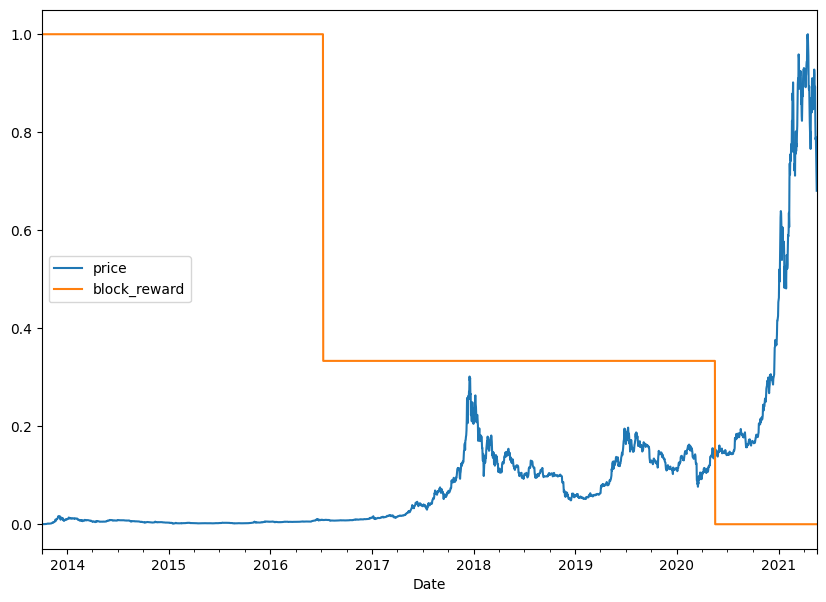

In [80]:
from sklearn.preprocessing import minmax_scale
scaled_price_block_df = pd.DataFrame(minmax_scale(bitcoin_prices_block[['price', 'block_reward']]),
                                     columns=bitcoin_prices_block.columns,
                                     index=bitcoin_prices_block.index)
scaled_price_block_df.plot(figsize=(10,7))

In [81]:
bitcoin_prices_block.tail()
len(bitcoin_prices_block)

2787

In [82]:
bitcoin_prices_windowed = bitcoin_prices_block.copy()

for i in range(WINDOW_SIZE):
  bitcoin_prices_windowed[f'Price+{i+1}'] = bitcoin_prices_windowed['price'].shift(periods=i+1)

bitcoin_prices_windowed[:10]

,price,block_reward,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
Date,,,,,,,,,
2013-10-01,123.65499,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-02,125.45500,25,123.65499,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-03,108.58483,25,125.45500,123.65499,NaN,NaN,NaN,NaN,NaN
2013-10-04,118.67466,25,108.58483,125.45500,123.65499,NaN,NaN,NaN,NaN
2013-10-05,121.33866,25,118.67466,108.58483,125.45500,123.65499,NaN,NaN,NaN
2013-10-06,120.65533,25,121.33866,118.67466,108.58483,125.45500,123.65499,NaN,NaN
2013-10-07,121.79500,25,120.65533,121.33866,118.67466,108.58483,125.45500,123.65499,NaN
2013-10-08,123.03300,25,121.79500,120.65533,121.33866,118.67466,108.58483,125.45500,123.65499
2013-10-09,124.04900,25,123.03300,121.79500,120.65533,121.33866,118.67466,108.58483,125.45500


In [83]:
X= bitcoin_prices_windowed.dropna().drop('price', axis=1).astype(np.float32)
y= bitcoin_prices_windowed.dropna()['price'].astype(np.float32)
len(X), len(y)

(2780, 2780)

In [84]:
split_size=int(len(X)*0.8)

X_train, y_train = X[:split_size], y[:split_size]
X_test, y_test = X[split_size:], y[split_size:]

len(X_train), len(y_train), len(X_test), len(y_test)

(2224, 2224, 556, 556)

In [85]:
tf.random.set_seed(42)

model_6 = tf.keras.Sequential([
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(HORIZON)
], name='model_6_multivariate')

model_6.compile(
    loss='mae',
    optimizer='Adam',
    metrics=['mae', 'mse']
)

model_6.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[create_model_checkpoint(model_name=model_6.name)]

)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 800.5217 - mae: 800.5217 - mse: 2859915.7500 - val_loss: 2482.4114 - val_mae: 2482.4114 - val_mse: 13650818.0000
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 237.4933 - mae: 237.4933 - mse: 256510.1875 - val_loss: 990.1111 - val_mae: 990.1111 - val_mse: 3331527.7500
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 172.0194 - mae: 172.0194 - mse: 148231.2969 - val_loss: 837.5020 - val_mae: 837.5020 - val_mse: 2261776.2500
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 146.3195 - mae: 146.3195 - mse: 112627.7500 - val_loss: 724.1064 - val_mae: 724.1064 - val_mse: 1811698.6250
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 130.1040 - mae: 130.1040 - mse: 93251.9766 - val_loss: 678.1607 - val_mae: 678.1607 - val_mse: 1536945.0000
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 122.2564 - mae: 122.2564 - mse: 83648.5469 - val_loss: 635.5573 - val_mae: 635.5573 - val_mse: 13

In [86]:
model_6.evaluate(X_test, y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 576.9858 - mae: 576.9858 - mse: 1180735.3750


[576.9857788085938, 576.9857788085938, 1180735.375]

In [87]:
model_6 = tf.keras.models.load_model('model_experiments/model_6_multivariate.keras')
model_6.evaluate(X_test, y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 566.5400 - mae: 566.5400 - mse: 1148828.0000


[566.5400390625, 566.5400390625, 1148828.0]

In [88]:
model_6_preds = tf.squeeze(model_6.predict(X_test))
model_6_preds[:10]

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8820.814, 8794.025, 9045.923, 8743.107, 8724.017, 8711.32 ,
       8663.07 , 8510.804, 8440.732, 8523.166], dtype=float32)>

In [89]:
model_6_results = evaluate_preds(y_test, model_6_preds)
model_6_results

{'mae': 566.5400390625,
 'mse': 1148828.0,
 'rmse': 1071.8338623046875,
 'mape': 2.5494680404663086,
 'mase': 0.9952539205551147}

In [90]:
naive_results

{'mae': 567.980224609375,
 'mse': 1147547.0,
 'rmse': 1071.2362060546875,
 'mape': 2.5165250301361084,
 'mase': 0.9995700120925903}

In [91]:
class NBeatsBlock(tf.keras.layers.Layer):
  def __init__(
      self,
      input_size: int,
      theta_size: int,
      horizon: int,
      n_neurons: int,
      n_layers: int,
      **kwargs
  ):
    super().__init__(**kwargs)
    self.input_size = input_size
    self.theta_size = theta_size
    self.horizon = horizon
    self.n_neurons = n_neurons
    self.n_layers = n_layers

    self.hidden = [tf.keras.layers.Dense(n_neurons, activation='relu') for _ in range(n_layers)]
    self.theta_layer = tf.keras.layers.Dense(theta_size, activation='linear', name='theta')

  def call(self, inputs):
    x = inputs
    for layer in self.hidden:
      x = layer(x)
    theta = self.theta_layer(x)
    backcast, forecast = theta[:, :self.input_size], theta[:, -self.horizon:]
    return backcast, forecast

In [92]:
dummy_n_beats_block_layer= NBeatsBlock(
    input_size=WINDOW_SIZE,
    theta_size=HORIZON + WINDOW_SIZE,
    horizon=HORIZON,
    n_neurons=128,
    n_layers=4,
    name='dummy_n_beats_block'
)



In [93]:
dummy_inputs=tf.expand_dims(tf.range(WINDOW_SIZE) + 1, axis=0)
dummy_inputs

<tf.Tensor: shape=(1, 7), dtype=int32, numpy=array([[1, 2, 3, 4, 5, 6, 7]], dtype=int32)>

In [94]:
backcast, forecast = dummy_n_beats_block_layer(dummy_inputs)
backcast.numpy(), forecast.numpy()

(array([[ 0.01781714, -0.36173767, -0.31533456,  0.05005135,  0.36339307,
         -0.13250445,  0.05500735]], dtype=float32),
 array([[0.7224974]], dtype=float32))

In [95]:
bitcoin_prices_nbeats = bitcoin_prices.copy()
for i in range(WINDOW_SIZE):
  bitcoin_prices_nbeats[f'Price+{i+1}'] = bitcoin_prices_nbeats['price'].shift(periods=i+1)

bitcoin_prices_nbeats.head()

,price,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
Date,,,,,,,,
2013-10-01,123.65499,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-02,125.45500,123.65499,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-03,108.58483,125.45500,123.65499,NaN,NaN,NaN,NaN,NaN
2013-10-04,118.67466,108.58483,125.45500,123.65499,NaN,NaN,NaN,NaN
2013-10-05,121.33866,118.67466,108.58483,125.45500,123.65499,NaN,NaN,NaN


In [96]:
X = bitcoin_prices_nbeats.dropna().drop('price', axis=1).astype(np.float32)
y = bitcoin_prices_nbeats.dropna()['price']

split_size = int(len(X) *0.8)
X_train, y_train = X[:split_size], y[:split_size]
X_test, y_test = X[split_size:], y[split_size:]
len(X_train), len(y_train), len(X_test), len(y_test)

(2224, 2224, 556, 556)

In [97]:
train_features_dataset = tf.data.Dataset.from_tensor_slices(X_train)
train_labels_dataset = tf.data.Dataset.from_tensor_slices(y_train)
test_features_dataset = tf.data.Dataset.from_tensor_slices(X_test)
test_labels_dataset = tf.data.Dataset.from_tensor_slices(y_test)

train_dataset = tf.data.Dataset.zip(train_features_dataset, train_labels_dataset)
test_dataset = tf.data.Dataset.zip(test_features_dataset, test_labels_dataset)

BATCH_SIZE=1024
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_dataset, test_dataset

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>)

In [98]:
N_EPOCHS = 5000
N_NEURONS = 512
N_LAYERS = 4
N_STACKS = 30

INPUT_SIZE = WINDOW_SIZE * HORIZON
THETA_SIZE = INPUT_SIZE + HORIZON

INPUT_SIZE, THETA_SIZE

(7, 8)

In [99]:
tensor_1 = tf.range(10) + 10
tensor_2 = tf.range(10)

subtract = layers.subtract([tensor_1, tensor_2])
add = layers.add([tensor_1, tensor_2])

subtract, add

(<tf.Tensor: shape=(10,), dtype=int32, numpy=array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10], dtype=int32)>,
 <tf.Tensor: shape=(10,), dtype=int32, numpy=array([10, 12, 14, 16, 18, 20, 22, 24, 26, 28], dtype=int32)>)

In [100]:
tf.random.set_seed(42)

nbeats_block_layer = NBeatsBlock(input_size=INPUT_SIZE,
                                 theta_size=THETA_SIZE,
                                 horizon=HORIZON,
                                 n_neurons=N_NEURONS,
                                 n_layers=N_LAYERS,
                                 name='nbeats_block_layer')

stack_input = layers.Input(shape=(INPUT_SIZE,), name='stack_input')

residuals, forecast = nbeats_block_layer(stack_input)

for i, _ in enumerate(range(N_STACKS - 1)):
  backcast, block_forecast = NBeatsBlock(
      input_size=INPUT_SIZE,
      theta_size=THETA_SIZE,
      horizon=HORIZON,
      n_neurons=N_NEURONS,
      n_layers=N_LAYERS,
      name=f'NBeatsBlock_{i}'
  )(residuals)
  residuals = layers.subtract([residuals, backcast])
  forecast = layers.add([forecast, block_forecast])


model_7 = tf.keras.Model(inputs=stack_input, outputs=forecast, name='model_7_nbeats')

model_7.compile(
    loss='mae',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae', 'mse']
)

model_7.fit(
    train_dataset,
    epochs=N_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=test_dataset,
    verbose=0,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=200, restore_best_weights=True),
               tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=100, verbose=1),
               create_model_checkpoint(model_name=model_7.name)]
)








Epoch 780: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 880: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.


In [101]:
model_7.evaluate(test_dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 574.3802 - mae: 574.3802 - mse: 1190957.8750


[574.3801879882812, 574.3801879882812, 1190957.875]

In [102]:
model_7_preds = make_preds(model_7, test_dataset)
model_7_preds[:10]

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8876.348 , 8782.603 , 9007.093 , 8786.056 , 8726.962 , 8726.758 ,
       8676.896 , 8527.346 , 8452.3955, 8515.857 ], dtype=float32)>

In [103]:
model_7_results = evaluate_preds(tf.squeeze(y_test), model_7_preds)
model_7_results

{'mae': 574.380126953125,
 'mse': 1190957.875,
 'rmse': 1091.3101806640625,
 'mape': 2.600444793701172,
 'mase': 1.0090267658233643}

In [104]:
from tensorflow.keras import layers


def get_ensemble_models(
    horizon=HORIZON,
    train_data=train_dataset,
    test_data=test_dataset,
    num_iter=10,
    num_epochs=1000,
    loss_fns=['mae', 'mse', 'mape']):
  ensemble_models=[]
  for i in range(num_iter):
    for loss_function in loss_fns:
      print(f'Optimising model by reducing: {loss_function} for {num_epochs} epochs, model_number{i}')
      model = tf.keras.Sequential([
          layers.Dense(128, kernel_initializer='he_normal', activation='relu'),
          layers.Dense(128, kernel_initializer='he_normal', activation='relu'),
          layers.Dense(horizon)
      ])

      model.compile(
          loss=loss_function,
          optimizer=tf.keras.optimizers.Adam(),
          metrics=['mae', 'mse']
      )

      model.fit(train_data,
                epochs=num_epochs,
                validation_data=test_data,
                verbose=0,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                            patience=200,
                                                            restore_best_weights=True),
                           tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                                patience=100,
                                                                verbose=1),
                           create_model_checkpoint(model_name=model.name)

                           ]
                )
      ensemble_models.append(model)
  return ensemble_models


In [105]:
ensemble_models=get_ensemble_models(num_iter=5, num_epochs=1000)

Optimising model by reducing: mae for 1000 epochs, model_number0

Epoch 259: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 797: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.

Epoch 897: ReduceLROnPlateau reducing learning rate to 1.0000000656873453e-06.
Optimising model by reducing: mse for 1000 epochs, model_number0

Epoch 301: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 401: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
Optimising model by reducing: mape for 1000 epochs, model_number0

Epoch 245: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
Optimising model by reducing: mae for 1000 epochs, model_number1
Optimising model by reducing: mse for 1000 epochs, model_number1

Epoch 441: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 541: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
Optimising model by reducing: mape

In [106]:
def make_ensemble_preds(ensemble_models, data):
  ensemble_preds=[]
  for model in ensemble_models:
    preds = model.predict(data)
    ensemble_preds.append(preds)
  return tf.constant(tf.squeeze(ensemble_preds))



In [107]:
ensemble_preds = make_ensemble_preds(ensemble_models, test_dataset)
ensemble_preds.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


TensorShape([15, 556])

In [108]:
ensemble_results = evaluate_preds(tf.squeeze(y_test), tf.squeeze(ensemble_preds))
ensemble_results

{'mae': 579.5636596679688,
 'mse': 1181035.25,
 'rmse': 1086.75439453125,
 'mape': 2.63474702835083,
 'mase': 1.0181328058242798}

In [109]:
ensemble_mean = tf.reduce_mean(ensemble_preds, axis=0)
ensemble_mean[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8797.034, 8786.384, 9067.034, 8730.185, 8756.939, 8726.68 ,
       8638.694, 8502.127, 8452.93 , 8530.989], dtype=float32)>

In [110]:
ensemble_median = np.median(ensemble_preds, axis=0)
ensemble_median[:10]

array([8791.377, 8784.371, 9073.818, 8726.17 , 8759.005, 8746.669,
       8647.747, 8505.629, 8459.869, 8540.79 ], dtype=float32)

In [111]:
ensemble_results = evaluate_preds(y_test, ensemble_mean)
ensemble_results

{'mae': 568.2864379882812,
 'mse': 1150192.25,
 'rmse': 1072.4700927734375,
 'mape': 2.572075366973877,
 'mase': 0.9983218908309937}

In [112]:
ensemble_results = evaluate_preds(y_test, ensemble_median)
ensemble_results

{'mae': 568.6925048828125,
 'mse': 1156169.5,
 'rmse': 1075.253173828125,
 'mape': 2.5702593326568604,
 'mase': 0.9990352392196655}

In [113]:
def get_upper_preds(preds):
  std = tf.math.reduce_std(preds, axis=0)
  intervel = 1.96 * std
  preds_mean = tf.math.reduce_mean(preds, axis=0)
  lower, upper = preds_mean - intervel, preds_mean + intervel
  return lower, upper

In [114]:
lower, upper = get_upper_preds(ensemble_preds)
lower[:10], upper[:10]

(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([8724.453 , 8713.819 , 8963.525 , 8619.3545, 8691.615 , 8628.244 ,
        8558.621 , 8452.039 , 8401.821 , 8472.6045], dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([8869.615, 8858.948, 9170.543, 8841.015, 8822.264, 8825.115,
        8718.768, 8552.215, 8504.038, 8589.374], dtype=float32)>)

In [115]:
X_test.index[:10]

DatetimeIndex(['2019-11-10', '2019-11-11', '2019-11-12', '2019-11-13',
               '2019-11-14', '2019-11-15', '2019-11-16', '2019-11-17',
               '2019-11-18', '2019-11-19'],
              dtype='datetime64[ns]', name='Date', freq=None)

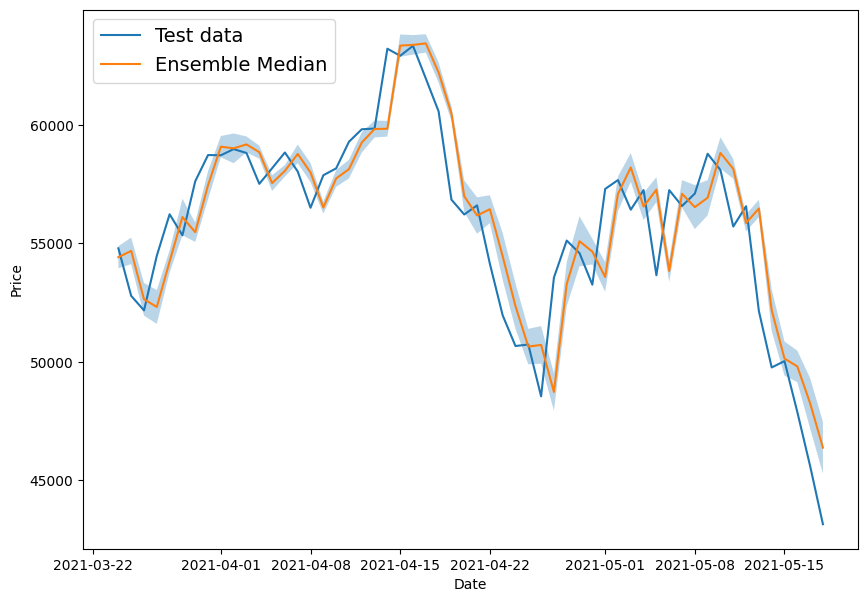

In [116]:
ensemble_median = np.median(ensemble_preds, axis=0)
import matplotlib.pyplot as plt


offset=500
plt.figure(figsize=(10,7))
plt.plot(X_test.index[offset:], y_test[offset:], '-', label='Test data')
plt.plot(X_test.index[offset:], ensemble_mean[offset:], '-', label='Ensemble Median')
plt.xlabel('Date')
plt.ylabel('Price')
plt.fill_between(X_test.index[offset:], (lower)[offset:], (upper)[offset:], alpha=0.3)
plt.legend(loc='upper left', fontsize=14)
plt.show()

In [117]:
X_all = bitcoin_prices_windowed.dropna().drop(['price','block_reward'], axis=1).to_numpy()
y_all = bitcoin_prices_windowed.dropna()['price'].to_numpy()
len(X_all), len(y_all)

(2780, 2780)

In [133]:
features_dataset_all = tf.data.Dataset.from_tensor_slices(X_all)
labels_dataset_all = tf.data.Dataset.from_tensor_slices(y_all)

dataset_all= tf.data.Dataset.zip((features_dataset_all, labels_dataset_all))

BATCH_SIZE=1024
dataset_all = dataset_all.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# dataset_all

In [137]:
print(type(dataset_all))
print(dataset_all)

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>


In [140]:
tf.random.set_seed(42)

model_9 = tf.keras.Sequential([
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(HORIZON)
], name='model_9_future_model')

model_9.compile(
    loss='mae',
    optimizer='adam',
    metrics=['mae', 'mse']
)

model_9.fit(
    dataset_all,
    epochs=100,
    callbacks=[create_model_checkpoint(model_name=model_9.name)]
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 308ms/step - loss: 6036.4087 - mae: 6036.4087 - mse: 129169688.0000
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 3811.2043 - mae: 3811.2043 - mse: 50774624.0000
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1585.5399 - mae: 1585.5399 - mse: 8507271.0000
Epoch 4/100
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 37.8050 - mae: 37.8050 - mse: 2967.3479

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 763.2335 - mae: 763.2335 - mse: 3637087.5000
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1315.8218 - mae: 1315.8218 - mse: 7757142.5000
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 856.1461 - mae: 856.1461 - mse: 3323107.7500
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 436.3552 - mae: 436.3552 - mse: 1151071.0000
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 659.1637 - mae: 659.1637 - mse: 2294827.7500
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 483.6388 - mae: 483.6388 - mse: 1252458.7500
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 425.3243 - mae: 425.3243 - mse: 1199499.3750
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 483.3714 - mae: 483.3714 - mse: 1379840.2500
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 366.4900 - mae: 366.4900 - mse: 868601.2500
Epoch 13/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 424.6945 - mae: 424.69

In [147]:
INTO_FUTURE=14

def make_future_forecast(values, model, into_future=INTO_FUTURE, window_size=WINDOW_SIZE):
  future_forecast=[]
  last_window = values[-WINDOW_SIZE:]

  for _ in range(INTO_FUTURE):
    future_pred=model.predict(tf.expand_dims(last_window, axis=0))
    print(f'Predicting on: \n{last_window} -> Prediction: {tf.squeeze(future_pred).numpy()}\n')

    future_forecast.append(tf.squeeze(future_pred).numpy())

    last_window = np.append(last_window, future_pred)[-WINDOW_SIZE:]

  return future_forecast


In [148]:

future_forecast = make_future_forecast(y_all, model_9, into_future=INTO_FUTURE, window_size=WINDOW_SIZE)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Predicting on: 
[56573.5554719  52147.82118698 49764.1320816  50032.69313676
 47885.62525472 45604.61575361 43144.47129086] -> Prediction: 54961.515625

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Predicting on: 
[52147.82118698 49764.1320816  50032.69313676 47885.62525472
 45604.61575361 43144.47129086 54961.515625  ] -> Prediction: 52424.50390625

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicting on: 
[49764.1320816  50032.69313676 47885.62525472 45604.61575361
 43144.47129086 54961.515625   52424.50390625] -> Prediction: 49171.6171875

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicting on: 
[50032.69313676 47885.62525472 45604.61575361 43144.47129086
 54961.515625   52424.50390625 49171.6171875 ] -> Prediction: 47600.640625

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicting on: 
[47885.62525472 45604.61575361 43144.47129086 54961.515625
 52424.50390625 49171.6171875  47600.640625  ] -> Prediction: 46757.98046875

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Pr

In [154]:
def get_future_dates(start_date, into_future, offset=1):
  start_date = start_date + np.timedelta64(offset, 'D')
  end_date = start_date + np.timedelta64(into_future, 'D')
  return np.arange(start_date, end_date, dtype='datetime64[D]')

In [155]:
last_timestep = bitcoin_prices.index[-1]
last_timestep

Timestamp('2021-05-18 00:00:00')

In [156]:
next_time_steps = get_future_dates(start_date=last_timestep, into_future=INTO_FUTURE)
next_time_steps

array(['2021-05-19', '2021-05-20', '2021-05-21', '2021-05-22',
       '2021-05-23', '2021-05-24', '2021-05-25', '2021-05-26',
       '2021-05-27', '2021-05-28', '2021-05-29', '2021-05-30',
       '2021-05-31', '2021-06-01'], dtype='datetime64[D]')

In [163]:
next_time_steps = np.insert(next_time_steps, 0, last_timestep)
future_forecast = np.insert(future_forecast, 0, bitcoin_prices.iloc[-1]['price'])
next_time_steps, future_forecast, len(next_time_steps), len(future_forecast)

(array(['2021-05-18', '2021-05-18', '2021-05-18', '2021-05-19',
        '2021-05-20', '2021-05-21', '2021-05-22', '2021-05-23',
        '2021-05-24', '2021-05-25', '2021-05-26', '2021-05-27',
        '2021-05-28', '2021-05-29', '2021-05-30', '2021-05-31',
        '2021-06-01'], dtype='datetime64[D]'),
 array([43144.473, 43144.473, 43144.473, 54961.516, 52424.504, 49171.617,
        47600.64 , 46757.98 , 47854.887, 48389.812, 53924.914, 50969.695,
        47885.29 , 47033.715, 48043.18 , 50233.14 , 50869.98 ],
       dtype=float32),
 17,
 17)

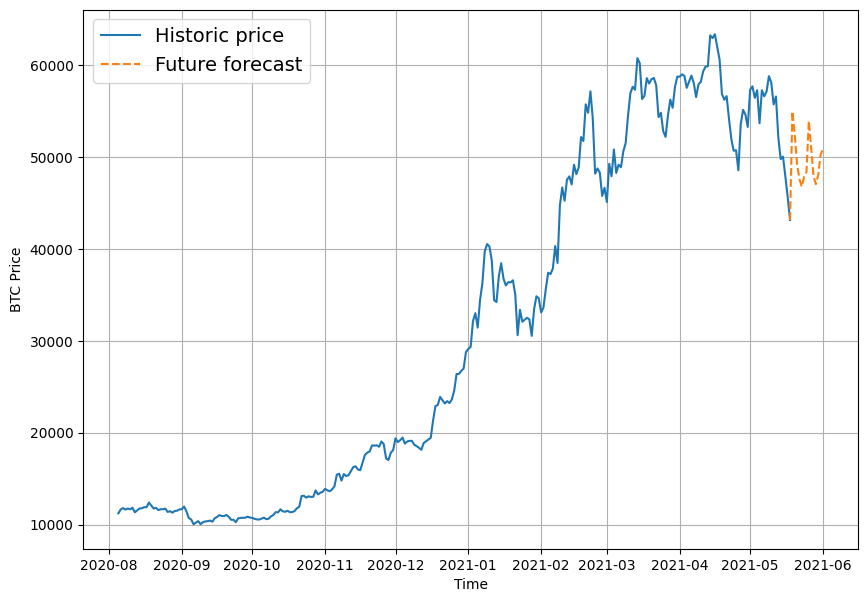

In [164]:
plt.figure(figsize=(10,7))
plot_time_series(bitcoin_prices.index, bitcoin_prices['price'], start=2500, format='-', label='Historic price')
plot_time_series(next_time_steps, future_forecast, start=0, format='--', label='Future forecast')

In [166]:
btc_price_turkey = btc_price.copy()
btc_price_turkey[-1] = btc_price_turkey[-1]/100

In [167]:
btc_price_turkey[-10:]

[58788.2096789273,
 58102.1914262342,
 55715.5466512869,
 56573.5554719043,
 52147.8211869823,
 49764.1320815975,
 50032.6931367648,
 47885.6252547166,
 45604.6157536131,
 431.44471290860304]

In [169]:
btc_timesteps_turkey = np.array(bitcoin_prices.index)
btc_timesteps_turkey[-10:]

array(['2021-05-09T00:00:00.000000000', '2021-05-10T00:00:00.000000000',
       '2021-05-11T00:00:00.000000000', '2021-05-12T00:00:00.000000000',
       '2021-05-13T00:00:00.000000000', '2021-05-14T00:00:00.000000000',
       '2021-05-15T00:00:00.000000000', '2021-05-16T00:00:00.000000000',
       '2021-05-17T00:00:00.000000000', '2021-05-18T00:00:00.000000000'],
      dtype='datetime64[ns]')

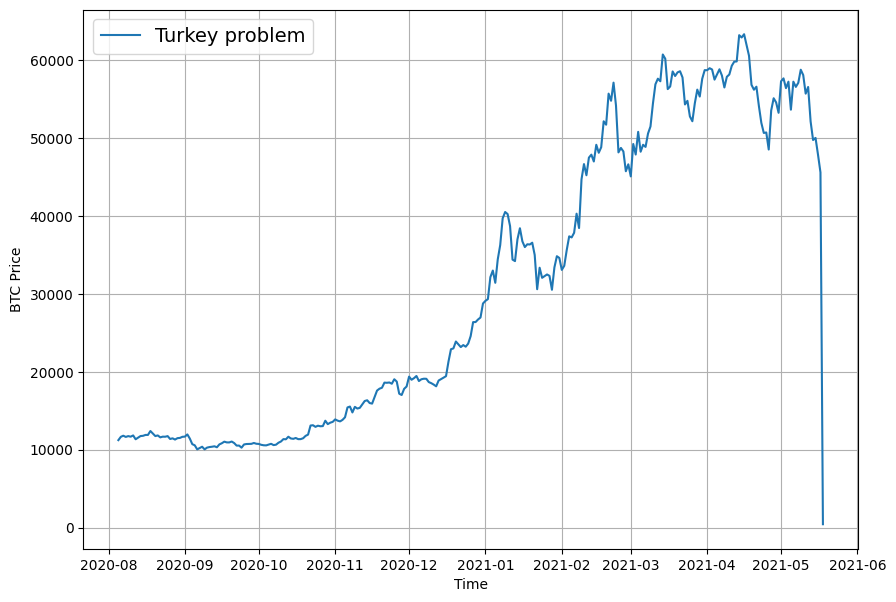

In [171]:
plt.figure(figsize=(10,7))
plot_time_series(btc_timesteps_turkey, btc_price_turkey, format='-', label='Turkey problem', start=2500)

In [173]:
full_windows, full_labels = make_windows(np.array(btc_price_turkey), WINDOW_SIZE, HORIZON)
full_windows.shape, full_labels.shape


((2780, 7), (2780, 1))

In [177]:
X_train, y_train, X_test, y_test = make_train_test_splits(full_windows, full_labels)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2224, 7), (2224, 1), (556, 7), (556, 1))

In [180]:
turkey_model = tf.keras.models.clone_model(model_1)
turkey_model.name = 'model_10_turkey_model'
turkey_model.compile(
    loss='mae',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae', 'mse']
)
turkey_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[create_model_checkpoint(model_name=turkey_model.name)])

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - loss: 1187.7395 - mae: 1187.7395 - mse: 5083569.0000 - val_loss: 2815.7104 - val_mae: 2815.7104 - val_mse: 24583790.0000
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 339.0818 - mae: 339.0818 - mse: 458875.6562 - val_loss: 1564.1331 - val_mae: 1564.1331 - val_mse: 10692811.0000
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 235.6569 - mae: 235.6569 - mse: 272588.4375 - val_loss: 1414.3341 - val_mae: 1414.3341 - val_mse: 9776662.0000
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 215.9958 - mae: 215.9958 - mse: 235594.8281 - val_loss: 1265.0007 - val_mae: 1265.0007 - val_mse: 9071331.0000
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 203.5422 - mae: 203.5422 - mse: 211710.0625 - val_loss: 1197.7495 - val_mae: 1197.7495 - val_mse: 8634757.0000
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 192.5561 - mae: 192.5561 - mse: 195124.7031 - val_loss: 1179.7692 - val_mae: 1179.7

In [181]:
turkey_model.evaluate(X_test, y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 651.1963 - mae: 651.1963 - mse: 4901064.0000


[651.1962890625, 651.1962890625, 4901064.0]

In [182]:
turkey_model = tf.keras.models.load_model('model_experiments/model_10_turkey_model.keras')
turkey_model.evaluate(X_test, y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 646.2432 - mae: 646.2432 - mse: 4814798.5000


[646.2432250976562, 646.2432250976562, 4814798.5]

In [183]:
turkey_model_preds = make_preds(turkey_model, X_test)
turkey_model_preds[:10]

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8859.874 , 8776.264 , 9048.327 , 8773.808 , 8710.817 , 8753.981 ,
       8692.6455, 8498.624 , 8469.392 , 8530.8125], dtype=float32)>

In [184]:
turkey_results = evaluate_preds(y_test, turkey_model_preds)
turkey_results

{'mae': 646.2431640625,
 'mse': 4814799.0,
 'rmse': 2194.264892578125,
 'mape': 21.334571838378906,
 'mase': 26.494342803955078}

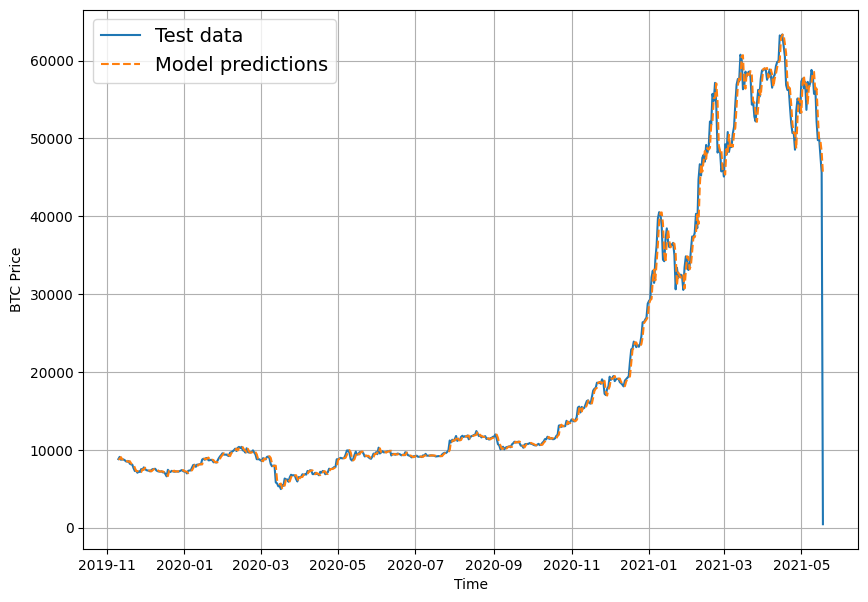

In [185]:
plt.figure(figsize=(10,7))
plot_time_series(btc_timesteps_turkey[-len(X_test):], btc_price_turkey[-len(X_test):], format='-', label='Test data')
plot_time_series(btc_timesteps_turkey[-len(X_test):], turkey_model_preds, format='--', label='Model predictions')


In [186]:
model_results = pd.DataFrame({
    'naive': naive_results,
    'model_1_dense_w7_h1': model_1_results,
    'model_2_dense_w30_h1': model_2_results,
    'model_3_dense_w30_h7': model_3_results,
    'model_4_CONV1D': model_4_results,
    'model_5_LSTM': model_5_results,
    'model_6_multivariate': model_6_results,
    'model_7_nbeats': model_7_results,
    'model_8_ensemble': ensemble_results,
    'model_10_turkey': turkey_results,
}).T

In [187]:
model_results

,mae,mse,rmse,mape,mase
naive,567.980225,1147547.000,1071.236206,2.516525,0.999570
model_1_dense_w7_h1,579.351685,1197777.500,1094.430176,2.611344,1.017760
model_2_dense_w30_h1,608.844421,1276730.625,1129.925049,2.805314,1.064266
model_3_dense_w30_h7,1267.433105,5535445.000,2352.752686,5.745019,2.255326
model_4_CONV1D,566.781738,1172773.875,1082.946899,2.542828,0.995679
model_5_LSTM,577.023621,1195985.000,1093.610962,2.572673,1.013671
model_6_multivariate,566.540039,1148828.000,1071.833862,2.549468,0.995254
model_7_nbeats,574.380127,1190957.875,1091.310181,2.600445,1.009027
model_8_ensemble,568.692505,1156169.500,1075.253174,2.570259,0.999035
model_10_turkey,646.243164,4814799.000,2194.264893,21.334572,26.494343


<Axes: >

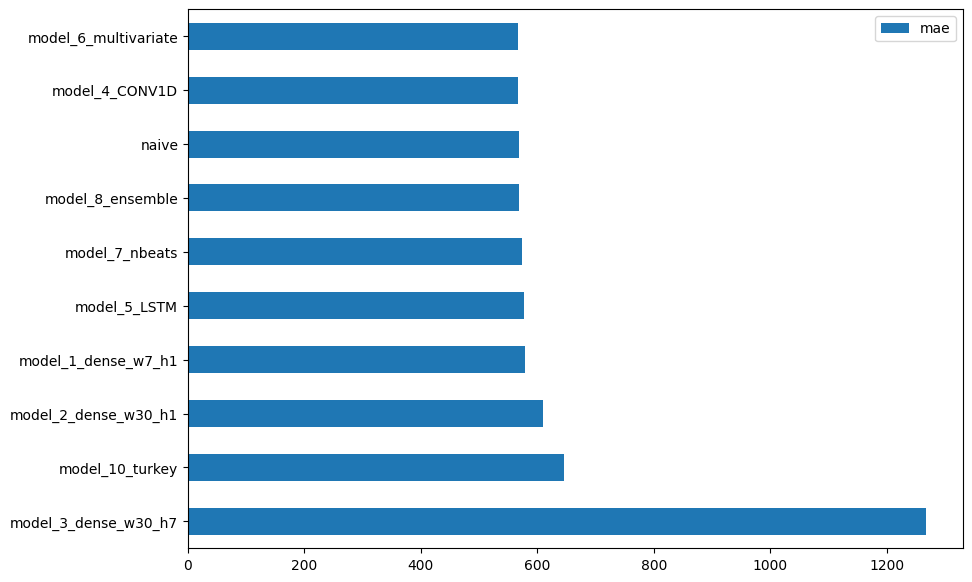

In [188]:
model_results[['mae']].sort_values('mae', ascending=False).plot(kind='barh', figsize=(10,7))